# L5 · Lab A — Build a Reward Model from Human Preferences

**RL for LLMs / RLHF — Vizuara AI Labs · Dr. Rajat Dandekar**

In the lecture we said: *there is no formula for a "good" answer, so we **learn** one from human comparisons.* This lab builds that learned reward model from scratch on the real **Anthropic HH-RLHF** preference data.

You will:
1. Load real human preference pairs `(prompt, chosen, rejected)`.
2. Put a **scalar head** on a transformer (gpt2) — the lecture's "swap the language head for a head that outputs one number."
3. Train it with the **Bradley-Terry** loss so it scores the *chosen* answer above the *rejected* one (**your one job**).
4. Watch preference accuracy climb above chance.

> Runtime: **GPU** (Runtime → Change runtime type → T4). ~10 minutes.


In [2]:
# ✅ PROVIDED — setup
!pip -q install "transformers==4.45.2" "datasets==3.0.1" >/dev/null
import torch, torch.nn.functional as F, random
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
device: cuda


## 1 · The data — real human preferences

Each row of HH-RLHF is two full conversations that share a prompt and differ in the assistant's reply: a **chosen** (human-preferred) one and a **rejected** one.

In [3]:
# ✅ PROVIDED — load a slice of Anthropic HH-RLHF
ds = load_dataset("Anthropic/hh-rlhf", split="train").shuffle(seed=0)
train = ds.select(range(8000))
test  = ds.select(range(8000, 8800))

ex = train[0]
print("CHOSEN  (preferred):\n", ex["chosen"][-400:])
print("\nREJECTED:\n", ex["rejected"][-400:])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

...

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

CHOSEN  (preferred):
 )

Human: What is the plot of Cast Away?

Assistant: It’s about a FedEx worker who's survived a plane crash and washed up on an island.

Human: Which movie would you most recommend from the list above?

Assistant: I really enjoyed A League of Their Own, although it's kind of dated.  Forrest Gump is also good, but I liked it less.  For me, The Green Mile was the best movie of the ones listed above.

REJECTED:
 n Mile  (1999)
-  Sling Blade  (1996)
- Saving Private Ryan  (1998)
- You've Got Mail  (1998)
- Angels in America  (2003)
- The Da Vinci Code  (2006)

Human: What is the plot of Cast Away?

Assistant: It’s about a FedEx worker who's survived a plane crash and washed up on an island.

Human: Which movie would you most recommend from the list above?

Assistant: I think The Green Mile is really good.


## 2 · The model — a transformer with a scalar head

A reward model is just a transformer whose language head is replaced by a **single linear layer to one number**. In 🤗 Transformers that is exactly `AutoModelForSequenceClassification(..., num_labels=1)`.

**Why left-truncation?** The chosen and rejected texts share the prompt and differ in the assistant's reply *at the end*. If we truncated from the right we'd cut off the very part that differs. So we keep the **end**.

In [16]:
# ✅ PROVIDED — tokenizer + transformer-with-a-scalar-head
tok = AutoTokenizer.from_pretrained("gpt2")
tok.pad_token = tok.eos_token
tok.truncation_side = "left"          # keep the ENDING, where chosen/rejected differ

model = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=1)
model.config.pad_token_id = tok.eos_token_id
model.to(device)

MAX_LEN, BS = 512, 8
def score(texts):
    enc = tok(texts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN).to(device)
    return model(**enc).logits.squeeze(-1)   # one scalar reward per text
print("reward model ready — params:", sum(p.numel() for p in model.parameters())//1_000_000, "M")

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


reward model ready — params: 124 M


## 3 · Evaluation — preference accuracy

A reward model is "good" if it scores the chosen answer above the rejected one. On a random model that happens ~50% of the time.

In [17]:
# ✅ PROVIDED — accuracy = fraction of test pairs where r(chosen) > r(rejected)
@torch.no_grad()
def eval_acc():
    model.eval(); correct = total = 0
    for i in range(0, len(test), BS):
        rc = score(test["chosen"][i:i+BS]); rr = score(test["rejected"][i:i+BS])
        correct += (rc > rr).sum().item(); total += len(rc)
    model.train(); return correct / total

print("accuracy BEFORE training:", round(eval_acc(), 4))   # ~0.50 (chance)

accuracy BEFORE training: 0.5125


## 4 · 📝 TODO — the Bradley-Terry loss

This is the heart of the lab. We want **P(chosen ≻ rejected) = σ(r_chosen − r_rejected)** to be large. Maximizing its log-likelihood = minimizing `−log σ(r_chosen − r_rejected)`.

Implement that one line. *(Hint: `F.logsigmoid`.)*

In [18]:
def bradley_terry_loss(r_chosen, r_rejected):
    # 📝 TODO: return the Bradley-Terry loss for a batch of (chosen, rejected) scores.
    # Want sigmoid(r_chosen - r_rejected) -> 1, i.e. minimize -log sigmoid(margin).
    # raise NotImplementedError("implement the Bradley-Terry loss")
    return -torch.mean(F.logsigmoid(r_chosen - r_rejected))

In [19]:
# ✅ PROVIDED — training loop (calls your loss)
opt = torch.optim.AdamW(model.parameters(), lr=2e-5)
idx = list(range(len(train))); random.seed(0); random.shuffle(idx)
acc_curve = [(0, eval_acc())]; step = 0
for i in range(0, len(idx), BS):
    b = idx[i:i+BS]
    rc = score([train["chosen"][j]   for j in b])
    rr = score([train["rejected"][j] for j in b])
    loss = bradley_terry_loss(rc, rr)            # <-- your TODO
    opt.zero_grad(); loss.backward(); opt.step(); step += 1
    if step % 100 == 0:
        a = eval_acc(); acc_curve.append((step, a))
        print(f"step {step:4d}  loss {loss.item():.4f}  margin {(rc-rr).mean():+.3f}  acc {a:.4f}")
print("accuracy AFTER training:", round(eval_acc(), 4))

step  100  loss 0.6478  margin +0.156  acc 0.5350
step  200  loss 0.5849  margin +0.266  acc 0.5387
step  300  loss 0.6123  margin +0.200  acc 0.5650
step  400  loss 0.6213  margin +0.170  acc 0.5650
step  500  loss 0.6055  margin +0.202  acc 0.5675
step  600  loss 0.6666  margin +0.082  acc 0.5625
step  700  loss 0.7427  margin -0.081  acc 0.5750
step  800  loss 0.6338  margin +0.156  acc 0.5650
step  900  loss 0.7006  margin +0.013  acc 0.5825
step 1000  loss 0.5962  margin +0.219  acc 0.5875
accuracy AFTER training: 0.5875


## 5 · Results

Plot the accuracy curve. On gpt2-small over the full HH mix you should reach **~0.57–0.60** — clearly above the 0.50 chance line. (Bigger models + more data push this higher; the point is that a *single scalar* learned purely from comparisons captures human preference.)

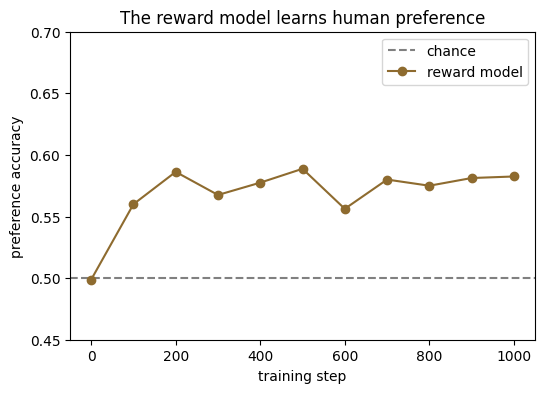

In [8]:
# ✅ PROVIDED — plot the climb
import matplotlib.pyplot as plt
xs, ys = zip(*acc_curve)
plt.figure(figsize=(6,4))
plt.axhline(0.5, ls="--", c="gray", label="chance")
plt.plot(xs, ys, "-o", c="#8E6B2F", label="reward model")
plt.xlabel("training step"); plt.ylabel("preference accuracy"); plt.ylim(0.45, 0.7)
plt.title("The reward model learns human preference"); plt.legend(); plt.show()

## 6 · Questions to answer

##1. The loss only uses the **difference** `r_chosen − r_rejected`. What does that say about the absolute reward values — and why will we need to **normalize** rewards before using them in PPO?

The model only learns about relative preference selection not absolute reward value. The reward model can say “chosen is better than rejected,” but it does not naturally learn that “reward = 5 means good”. If rewards are too large, PPO updates become too aggressive. The policy may move too far and collapse or over-optimize the reward model. If rewards are too small, learning becomes weak and slow. If rewards have a weird offset, the value model has to learn an unnecessary baseline, and advantage estimates become unstable.

In [12]:
# 2. We left-truncated the input. Predict what happens to the final accuracy if you switch to `truncation_side="right"`. (Try it.)
tok = AutoTokenizer.from_pretrained("gpt2")
tok.pad_token = tok.eos_token
tok.truncation_side = "right"          # keep the ENDING, where chosen/rejected differ

model = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=1)
model.config.pad_token_id = tok.eos_token_id
model.to(device)

opt = torch.optim.AdamW(model.parameters(), lr=2e-5)
idx = list(range(len(train))); random.seed(0); random.shuffle(idx)
acc_curve = [(0, eval_acc())]; step = 0
for i in range(0, len(idx), BS):
    b = idx[i:i+BS]
    rc = score([train["chosen"][j]   for j in b])
    rr = score([train["rejected"][j] for j in b])
    loss = bradley_terry_loss(rc, rr)            # <-- your TODO
    opt.zero_grad(); loss.backward(); opt.step(); step += 1
    if step % 100 == 0:
        a = eval_acc(); acc_curve.append((step, a))
        print(f"step {step:4d}  loss {loss.item():.4f}  margin {(rc-rr).mean():+.3f}  acc {a:.4f}")
print("accuracy AFTER training:", round(eval_acc(), 4))

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


step  100  loss 0.7232  margin +0.029  acc 0.5463
step  200  loss 0.7176  margin +0.011  acc 0.5312
step  300  loss 0.5696  margin +0.346  acc 0.5050
step  400  loss 0.7423  margin -0.064  acc 0.5300
step  500  loss 0.6184  margin +0.168  acc 0.5437
step  600  loss 0.6193  margin +0.212  acc 0.5325
step  700  loss 0.7435  margin -0.081  acc 0.5288
step  800  loss 0.7329  margin -0.064  acc 0.5275
step  900  loss 0.7556  margin -0.101  acc 0.5400
step 1000  loss 0.5389  margin +0.347  acc 0.5700
accuracy AFTER training: 0.57


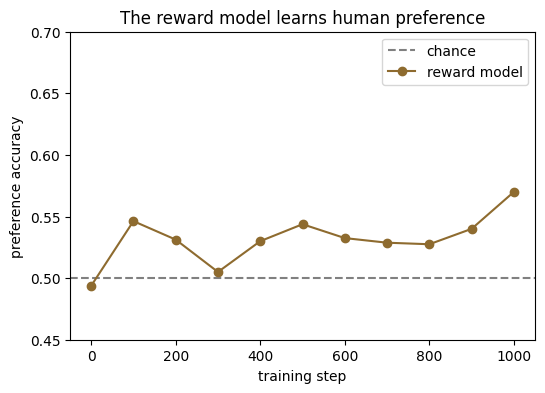

In [13]:
# ✅ PROVIDED — plot the climb
import matplotlib.pyplot as plt
xs, ys = zip(*acc_curve)
plt.figure(figsize=(6,4))
plt.axhline(0.5, ls="--", c="gray", label="chance")
plt.plot(xs, ys, "-o", c="#8E6B2F", label="reward model")
plt.xlabel("training step"); plt.ylabel("preference accuracy"); plt.ylim(0.45, 0.7)
plt.title("The reward model learns human preference"); plt.legend(); plt.show()

Right truncation reached a final preference accuracy of around 57%, while left truncation reached around 58–59%. Both are above random chance, but left truncation performed slightly better and looked more stable. This suggests that keeping the later tokens, usually the assistant’s final response, preserves more useful preference signal than keeping only the beginning of the sequence.


## 3. Accuracy plateaus well below 100%. Name two reasons (think: model size, label noise in human preferences).

Model capacity is limited
The reward model may be too small to capture all subtle human preferences. Some chosen/rejected pairs differ in nuanced ways like helpfulness, harmlessness, tone, factuality, or completeness. A small model can learn broad patterns but will miss harder distinctions.
Human preference labels are noisy
Human judgments are not perfectly consistent. Two annotators may disagree, or the same annotator may choose differently depending on context. Some “chosen” answers may not actually be clearly better than “rejected” answers. So even a strong model cannot reach 100% accuracy because the labels themselves are imperfect.

So the plateau does not automatically mean training failed. It means reward modeling is learning from a noisy, subjective signal with limited model capacity.

In [21]:
## 4. **Save your reward model** (`model.save_pretrained("rm")`) — you'll plug it into the flagship RLHF project as the reward signal.
model.save_pretrained("rm")